<a href="https://colab.research.google.com/github/DrakeJay/kardia/blob/main/U_Net_Transfer_V3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

base_path = '/content/drive/MyDrive/kaggle_data/competitions/physionet-ecg-image-digitization/'
test_csv_path = os.path.join(base_path, 'test.csv')
test_img_dir = os.path.join(base_path, 'test/')

if os.path.exists(test_csv_path) and os.path.exists(test_img_dir):
    print(f"Found test.csv at {test_csv_path} test directory at {test_img_dir}")
else:
    print("Error:paths do not exist.")
    print(f"test.csv good: {os.path.exists(test_csv_path)}")
    print(f"test directory good: {os.path.exists(test_img_dir)}")

Success: Found test.csv at /content/drive/MyDrive/kaggle_data/competitions/physionet-ecg-image-digitization/test.csv and test directory at /content/drive/MyDrive/kaggle_data/competitions/physionet-ecg-image-digitization/test/


In [3]:
import torch
import glob
import os
import yaml
import sys
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from torchvision.io import read_image
import torch.nn.functional as F
from torch import Tensor


sys.path.insert(0, '/content/drive/MyDrive/kardia/Open-ECG-Digitizer-main')

from src.model.unet import UNet
from src.model.perspective_detector import PerspectiveDetector
from src.model.cropper import Cropper
from src.model.pixel_size_finder import PixelSizeFinder
from src.model.signal_extractor import SignalExtractor
from src.model.lead_identifier import LeadIdentifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")




















#####################Functions

def add_noise_to_image(input_img, sigma=2, opacity=0.2):
    noise = torch.sigmoid(torch.randn_like(input_img) * sigma)
    input_img = (1-opacity)*input_img + opacity * noise
    return input_img




def load_model(weights_path, **kwargs):
    model = UNet(
        num_in_channels=kwargs.get("num_in_channels", 3),
        num_out_channels=kwargs.get("num_out_channels", 4),




        dims=kwargs.get("dims", [32, 64, 128, 256, 320, 320, 320, 320]),
        depth=kwargs.get("depth", 2),
    )


    state_dict = torch.load(weights_path, map_location=device, weights_only=False)
    state_dict = {k.replace("_orig_mod.", ""): v for k, v in state_dict.items()}
    model.load_state_dict(state_dict)
    model.eval().to(device)
    return model




def load_png_file(path):


    img = read_image(path)
    img = img.float() / 255.0
    img = img.unsqueeze(0)


    if img.shape[1] > 3:
        img = img[:, :3, :, :]
    return img

def _crop_y(image: Tensor, signal_prob: Tensor, grid_prob: Tensor, text_prob: Tensor) -> tuple:

    def get_bounds(tensor: Tensor) -> tuple[int, int]:
        prob = torch.clamp(
            tensor.squeeze().sum(dim=tensor.dim() - 3)


            - tensor.squeeze().sum(dim=tensor.dim() - 3).mean(),
            min=0,
        )
        non_zero = (prob > 0).nonzero(as_tuple=True)[0]
        if non_zero.numel() == 0:
            return 0, tensor.shape[2] - 1
        return int(non_zero[0].item()), int(non_zero[-1].item())

    y1, y2 = get_bounds(signal_prob + grid_prob)

    slices = (slice(None), slice(None), slice(y1, y2 + 1), slice(None))

    return image[slices], signal_prob[slices], grid_prob[slices], text_prob[slices]






def _align_feature_maps(cropper, image, signal_prob, grid_prob, text_prob, source_points) -> tuple:

    aligned_signal_prob = cropper.apply_perspective(signal_prob, source_points, fill_value=0)

    aligned_image = cropper.apply_perspective(image, source_points, fill_value=0)

    aligned_grid_prob = cropper.apply_perspective(grid_prob, source_points, fill_value=0)

    aligned_text_prob = cropper.apply_perspective(text_prob, source_points, fill_value=0)

    return _crop_y(aligned_image, aligned_signal_prob, aligned_grid_prob, aligned_text_prob)



#CRRRRROOOP
def crop_image(image, probs):
    perspective_detector = PerspectiveDetector(num_thetas=200)
    cropper = Cropper(percentiles=(0.03, 0.97), alpha=0.99)

    alignment_params = perspective_detector(probs[0, 0])
    source_points = cropper(probs[0, 1], alignment_params)
    signal_prob, grid_prob, text_prob = probs[:, [2]], probs[:, [0]], probs[:, [1]]

    return _align_feature_maps(cropper, image, signal_prob, grid_prob, text_prob, source_points)






def extract_signals(aligned_signal_prob, aligned_grid_prob, aligned_text_prob, target_num_samples) -> dict:
    pixel_size_finder = PixelSizeFinder(min_number_of_grid_lines=30, max_number_of_grid_lines=100, lower_grid_line_factor=0.1)
    signal_extractor = SignalExtractor()



    layout_unet = load_model(
        weights_path="/content/drive/MyDrive/kardia/Open-ECG-Digitizer-main/weights/lead_name_unet_weights_07072025.pt",
        num_in_channels=1, num_out_channels=13, dims=[32, 64, 128, 256, 256], depth=2, device=device
    )




    config_path = os.path.join(sys.path[0], "src/config/lead_layouts_george-moody-2024.yml")
    with open(config_path, "r") as f: layouts = yaml.safe_load(f)



    identifier = LeadIdentifier(
        layouts=layouts, unet=layout_unet, device=device, possibly_flipped=False,
        target_num_samples=target_num_samples, required_valid_samples=2
    )



    mm_per_pixel_x, mm_per_pixel_y = pixel_size_finder(aligned_grid_prob)
    avg_pixel_per_mm = (1 / mm_per_pixel_x + 1 / mm_per_pixel_y) / 2



    signals = signal_extractor(aligned_signal_prob.squeeze())

    signals = identifier(signals, aligned_text_prob, avg_pixel_per_mm=avg_pixel_per_mm)

    signals['avg_pixel_per_mm'] = float(avg_pixel_per_mm)
    return signals




def resample_image(image, resample_size):
    height, width = image.shape[2], image.shape[3]
    max_dim = max(height, width)



    if max_dim > resample_size:
        scale = resample_size / max_dim
        new_size = (int(height * scale), int(width * scale))
        return F.interpolate(image, size=new_size, mode="bilinear", align_corners=False, antialias=True)


    return image



# GET THE MODEL
model = load_model(
    weights_path="/content/drive/MyDrive/kardia/Open-ECG-Digitizer-main/weights/unet_weights_07072025(1).pt",
    num_in_channels=3, num_out_channels=4, dims=[32, 64, 128, 256, 320, 320, 320, 320], depth=2
)


test_csv_path = '/content/drive/MyDrive/kaggle_data/competitions/physionet-ecg-image-digitization/test.csv'
test_df = pd.read_csv(test_csv_path)
sample_ids = test_df['id'].unique()[:3]

sample_results = {}

print("Starting")

for pid in sample_ids:
    start_time = time.time()
    img_path = f"/content/drive/MyDrive/kaggle_data/competitions/physionet-ecg-image-digitization/test/{pid}.png"

    # Load

    input_img = load_png_file(img_path)
    input_img = add_noise_to_image(input_img)
    input_img = resample_image(input_img, resample_size=3200)





    with torch.no_grad():
        logits = model(input_img.to(device))
        output_probs = torch.softmax(logits, dim=1)

    #
    signal_conf = output_probs[0, 2][output_probs[0, 2] > 0.5].mean().item() if (output_probs[0, 2] > 0.5).sum() > 0 else 0.0



    # All the alignment stuff crop
    aligned_image, aligned_signal, aligned_grid, aligned_text = crop_image(input_img, output_probs)


    row = test_df[test_df.id == pid].iloc[0]
    target_fs = row.fs * 10 # As per previous logic

    lines_dict = extract_signals(aligned_signal, aligned_grid, aligned_text, target_num_samples=target_fs)

    elapsed = time.time() - start_time
    print(f"ID: {pid} | Time: {elapsed:.2f}s | Conf: {signal_conf:.4f} | Scale: {lines_dict.get('avg_pixel_per_mm', 0):.2f} px/mm")











    sample_results[pid] = {
        'image': input_img.cpu(),
        'probs': output_probs.cpu(),
        'aligned_signal': aligned_signal.cpu(),
        'aligned_grid': aligned_grid.cpu(),
        'lines': lines_dict['canonical_lines']
    }


Starting inference on 3 samples...
ID: 1053922973 | Time: 15.66s | Conf: 0.5322 | Scale: 7.55 px/mm
ID: 2352854581 | Time: 16.05s | Conf: 0.5297 | Scale: 7.55 px/mm


Visualizing results for processed samples...


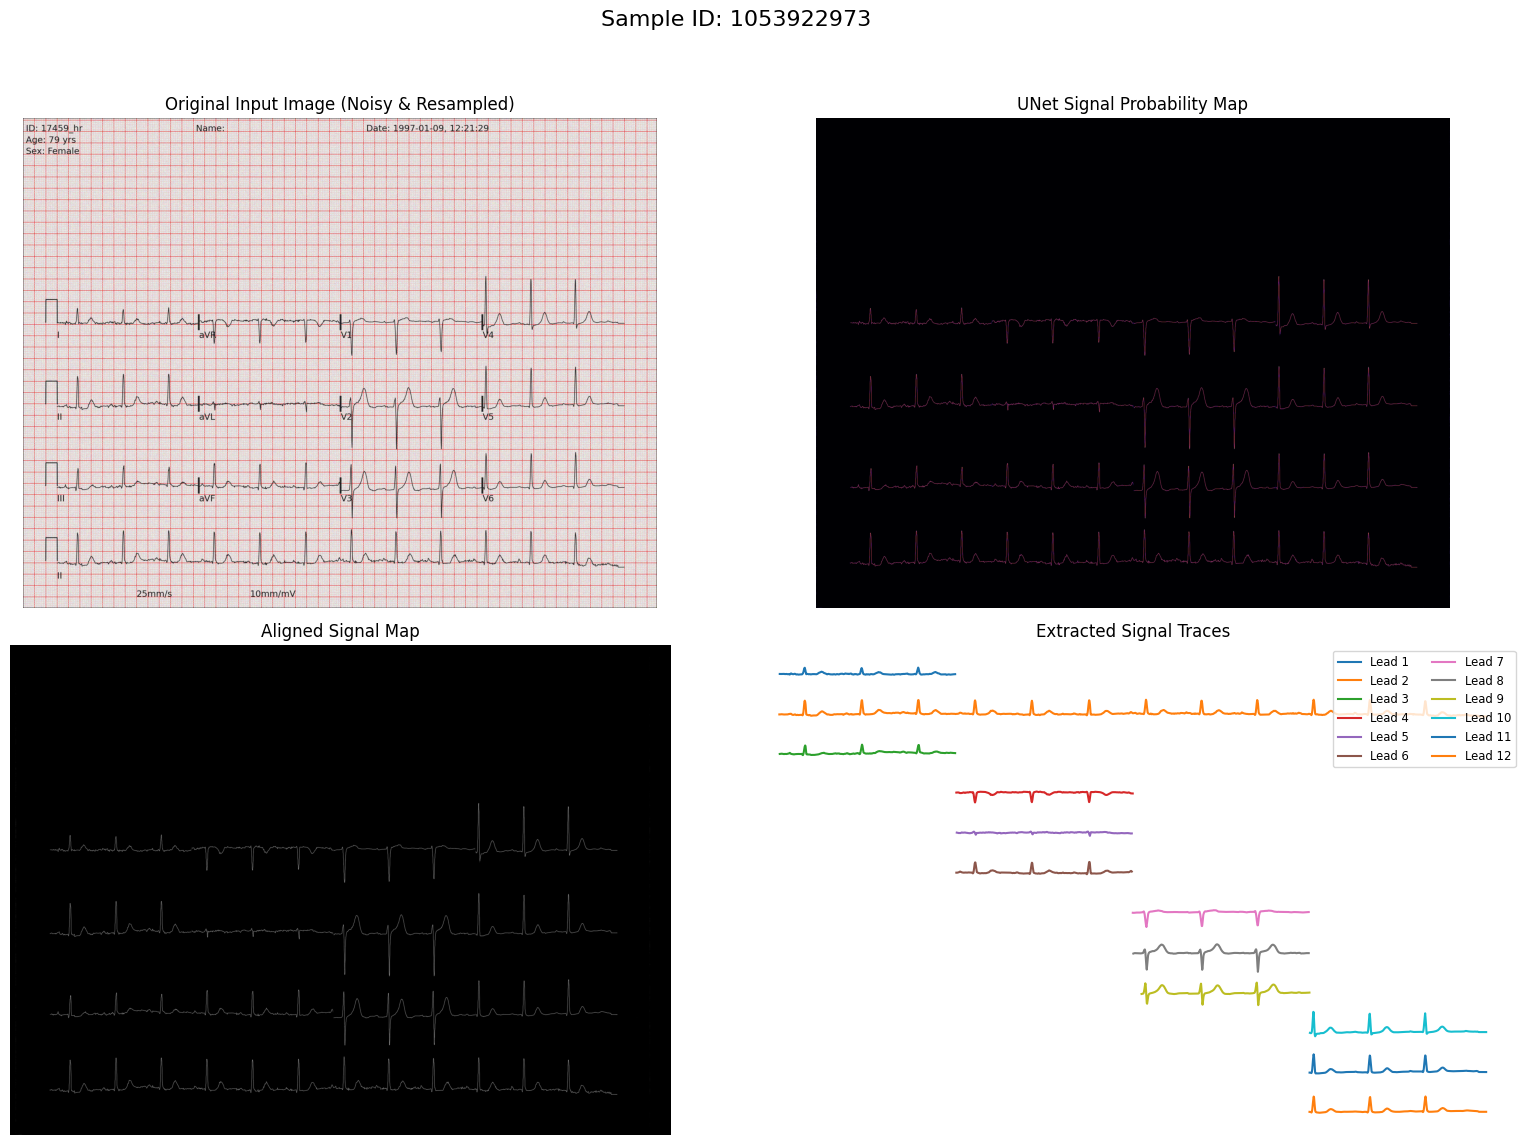

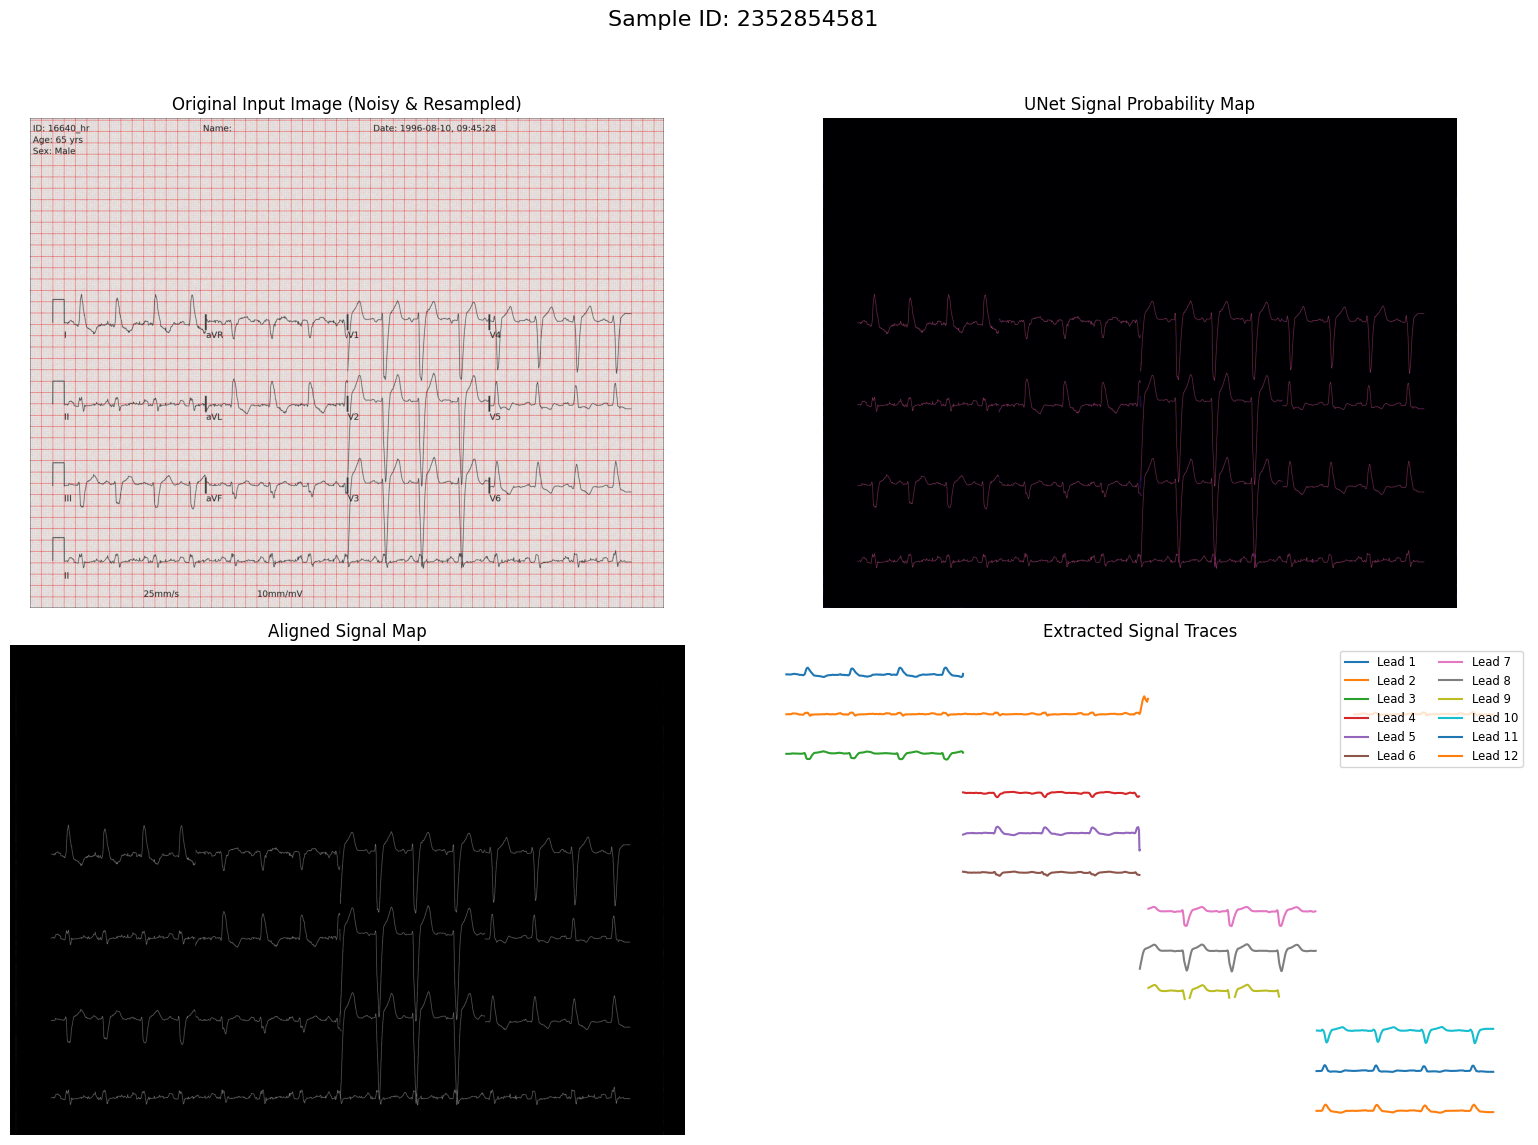

In [4]:
import matplotlib.pyplot as plt
import numpy as np

print("Visualizing")

for pid, data in sample_results.items():
    input_img = data['image']
    probs = data['probs']
    aligned_signal = data['aligned_signal']
    lines = data['lines']

    # Pre
    fig, axs = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f"Sample ID: {pid}", fontsize=16)

    # Orig Input Image

    # Image shhape (1, 3, H, W)
    # convert to (H, W, 3)
    img_np = input_img.squeeze(0).permute(1, 2, 0).numpy()

    axs[0, 0].imshow(img_np)

    axs[0, 0].set_title("Original Input Image (Noisy & Resampled)")

    axs[0, 0].axis("off")




    # Signal Channel

    # Probs (1, 4, H, W), sihgnal channel index 2
    signal_prob = probs[0, 2].numpy()
    axs[0, 1].imshow(signal_prob, cmap='magma')

    axs[0, 1].set_title("UNet Signal Probability Map")

    axs[0, 1].axis("off")

    #  Aligned Signal Map
    # Aligned signal shape is (1, 1, H, W) or similar
    aligned_sig_np = aligned_signal.squeeze().numpy()
    axs[1, 0].imshow(aligned_sig_np, cmap='gray')
    axs[1, 0].set_title("Aligned Signal Map")
    axs[1, 0].axis("off")

    #  Extracted Signal Lines
    # Lines shapppe: (num_leads, num_samples)
    axs[1, 1].set_title("Extracted Signal Traces")
    num_leads = lines.shape[0]

    # Seppeprate Plot leads with offsets
    offset_step = np.nanmax(np.abs(lines.numpy())) * 2 if not np.isnan(lines.numpy()).all() else 100
    if offset_step == 0: offset_step = 100

    for i in range(num_leads):
        # Check
        line_data = lines[i].numpy()
        if not np.isnan(line_data).all():
             axs[1, 1].plot(line_data - (i * offset_step), label=f"Lead {i+1}")

    axs[1, 1].legend(loc='upper right', fontsize='small', ncol=2)
    axs[1, 1].axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [5]:
import pandas as pd
import numpy as np
import torch
import os
import time
import sys

# Define constants and helper functions
leads_names = ['I','II','III','aVR','aVL','aVF','V1','V2','V3','V4','V5','V6']

def get_slice(lead_name: str, number_of_rows: int):
    """Returns the slice object for extracting the valid signal segment."""
    if lead_name in ['I', 'II', 'III']:
        return slice(0, number_of_rows)
    elif lead_name in ['aVR', 'aVL', 'aVF']:
        return slice(number_of_rows, 2 * number_of_rows)
    elif lead_name in ['V1', 'V2', 'V3']:
        return slice(2 * number_of_rows, 3 * number_of_rows)
    elif lead_name in ['V4', 'V5', 'V6']:
        return slice(3 * number_of_rows, 4 * number_of_rows)
    else:
        return slice(0, number_of_rows)

# Setup paths
output_path = '/content/drive/MyDrive/kaggle_data/competitions/physionet-ecg-image-digitization/output.csv'
test_csv_path = '/content/drive/MyDrive/kaggle_data/competitions/physionet-ecg-image-digitization/test.csv'
test_img_dir = '/content/drive/MyDrive/kaggle_data/competitions/physionet-ecg-image-digitization/test/'

# Initialize output file
if os.path.exists(output_path):
    os.remove(output_path)
with open(output_path, 'w') as f:
    f.write("id,value\n")

# Load test dataframe
test_df = pd.read_csv(test_csv_path)
unique_ids = test_df['id'].unique()

print(f"Starting full inference on {len(unique_ids)} files...")







for pid in unique_ids:
    start_time = time.time()
    img_path = os.path.join(test_img_dir, f"{pid}.png")

    try:



        #Load Image

        if not os.path.exists(img_path):
            print(f"Warning: Image {img_path} not found. Skipping.")
            continue


        input_img = load_png_file(img_path)


        # Preprocess
        input_img = add_noise_to_image(input_img)
        input_img = resample_image(input_img, resample_size=3200)


        with torch.no_grad():
            logits = model(input_img.to(device))
            output_probs = torch.softmax(logits, dim=1)

        #Crop and Align
        aligned_image, aligned_signal, aligned_grid, aligned_text = crop_image(input_img, output_probs)

        # e. Calculate target samples (fs * 10s)
        id_rows = test_df[test_df['id'] == pid]
        fs = id_rows.iloc[0]['fs']
        target_num_samples = int(fs * 10)

        # f. Extract Signals
        lines_dict = extract_signals(aligned_signal, aligned_grid, aligned_text, target_num_samples=target_num_samples)

        # g. Convert to mV
        raw_lines = lines_dict["canonical_lines"] # Shape (12, samples)
        lines_mv = raw_lines * 1e-3
        lines_mv_np = lines_mv.cpu().numpy()

        # h. Process each required lead
        chunk_data = []
        for _, row in id_rows.iterrows():
            lead_name = row.lead
            number_of_rows = row.number_of_rows

            if lead_name not in leads_names:
                continue

            # ii. Select Channel
            lead_idx = leads_names.index(lead_name)
            lead_signal = lines_mv_np[lead_idx]

            # iii. Slice
            slc = get_slice(lead_name, number_of_rows)
            segment = lead_signal[slc]

            # iv. Handle NaNs
            if np.isnan(segment).all():
                segment = np.zeros(number_of_rows)
            else:
                mean_val = np.nanmean(segment)
                segment = np.nan_to_num(segment, nan=mean_val)

            # v. Ensure length matches
            if len(segment) != number_of_rows:
                if len(segment) > number_of_rows:
                    segment = segment[:number_of_rows]
                else:
                    pad_width = number_of_rows - len(segment)
                    segment = np.pad(segment, (0, pad_width), 'edge')



            row_ids = [f"{pid}_{t}_{lead_name}" for t in range(number_of_rows)]

            #
            chunk_data.extend(list(zip(row_ids, segment)))



        if chunk_data:
            chunk_df = pd.DataFrame(chunk_data, columns=['id', 'value'])
            chunk_df.to_csv(output_path, mode='a', header=False, index=False)

        elapsed = time.time() - start_time
        print(f"Processed {pid}: {elapsed:.2f}s")

    except Exception as e:
        print(f"Error  {pid}: {str(e)}")
        continue

print(" complete saved to output.csv.")

Starting full inference on 2 files...
Processed 1053922973: 9.61s
Processed 2352854581: 11.71s
Full inference complete. Results saved to output.csv.


In [ ]:
import pandas as pd

output_path = '/content/drive/MyDrive/kaggle_data/competitions/physionet-ecg-image-digitization/output.csv'
if os.path.exists(output_path):
    df_output = pd.read_csv(output_path)
    print(f"Output file found with shape: {df_output.shape}")
    print(df_output.head())
else:
    print("Output file not found.")

Output file found with shape: (75000, 2)
               id     value
0  1053922973_0_I -0.019339
1  1053922973_1_I -0.019339
2  1053922973_2_I -0.019339
3  1053922973_3_I -0.019339
4  1053922973_4_I -0.019339
